### Retrieve the necessary Packages

In [25]:
# pip install boto3
# !pip install pandas matplotlib seaborn wordcloud

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

#Necessary for API calls on Polygon.io
import boto3
from botocore.config import Config
import requests

# Set the display option to show full column length
pd.set_option('display.max_colwidth', None)

## Reference from Polygon.io documentation
https://polygon.io/knowledge-base/article/how-to-get-started-with-s3

In [90]:
# Test API Key
import requests

# Define the API key and base URL
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'
base_url = 'https://api.polygon.io/v2/reference/news'

# Simple function to test the API key
def test_api_key(api_key):
    url = f"{base_url}?ticker=AAPL&limit=1&apiKey={api_key}"
    response = requests.get(url)
    if response.status_code == 401:
        print("Unauthorized request. Please check your API key and permissions.")
    elif response.status_code == 200:
        print("API key is valid.")
    else:
        print(f"Unexpected error: {response.status_code}, {response.text}")

# Test the API key
test_api_key(api_key)

API key is valid.


## Download Stock Daily AggregateData Manually to flat files from 2018 to 2023

In [31]:
# Initialize a session using your credentials
session = boto3.Session(
    aws_access_key_id='9ebb8b17-c9b8-4148-8f27-de81261c8a42',
    aws_secret_access_key='EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru',
)

# Create a client with your session and specify the endpoint
s3 = session.client(
    's3',
    endpoint_url='https://files.polygon.io',
    config=Config(signature_version='s3v4'),
)

# Initialize a paginator for listing objects
paginator = s3.get_paginator('list_objects_v2')

# Choose the appropriate prefix depending on the data you need
prefix = 'us_stocks_sip/day_aggs_v1/2018/'  # Example prefix for 2023 data

# Specify the bucket name
bucket_name = 'flatfiles'

# Create a local directory to save the downloaded files
local_directory = 's3_files'
os.makedirs(local_directory, exist_ok=True)

# List and download objects using the selected prefix
for page in paginator.paginate(Bucket=bucket_name, Prefix=prefix):
    for obj in page.get('Contents', []):
        object_key = obj['Key']
        
        # Specify the local file name and path to save the downloaded file
        local_file_name = object_key.split('/')[-1]
        local_file_path = os.path.join(local_directory, local_file_name)

        # Download the file
        s3.download_file(bucket_name, object_key, local_file_path)
        print(f'Downloaded {object_key} to {local_file_path}')

print("All files downloaded successfully.")


Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-02.csv.gz to s3_files\2018-01-02.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-03.csv.gz to s3_files\2018-01-03.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-04.csv.gz to s3_files\2018-01-04.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-05.csv.gz to s3_files\2018-01-05.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-08.csv.gz to s3_files\2018-01-08.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-09.csv.gz to s3_files\2018-01-09.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-10.csv.gz to s3_files\2018-01-10.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-11.csv.gz to s3_files\2018-01-11.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-12.csv.gz to s3_files\2018-01-12.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-16.csv.gz to s3_files\2018-01-16.csv.gz
Downloaded us_stocks_sip/day_aggs_v1/2018/01/2018-01-17.csv.gz to s3_f

### View the Data Sample

In [21]:
# Specify the local file path to one of the downloaded files
local_file_path = 's3_files/2023-12-29.csv.gz'  # Replace with any file name

# Read the compressed CSV file
df = pd.read_csv(local_file_path, compression='gzip')

# Display the first few rows of the DataFrame
df.head(20)

,ticker,volume,open,close,high,low,window_start,transactions
0,A,986297,139.0700,139.030000,139.700000,138.3600,1703826000000000000,22868
1,AA,3275998,34.3100,34.000000,34.740000,33.9300,1703826000000000000,34799
2,AAA,6303,25.0200,24.960000,25.033600,24.9600,1703826000000000000,42
3,AAAU,1690041,20.4150,20.435000,20.490000,20.4000,1703826000000000000,2164
4,AACG,33772,1.2200,1.159700,1.270000,1.1109,1703826000000000000,265
5,AACI,660,10.7700,10.770000,10.770000,10.7700,1703826000000000000,13
6,AACIW,10534,0.0250,0.018001,0.025100,0.0151,1703826000000000000,21
7,AACT,6445,10.4500,10.440000,10.470000,10.4200,1703826000000000000,82
8,AACT.WS,6000,0.1601,0.152100,0.160100,0.1521,1703826000000000000,47
9,AADI,647375,2.1000,2.020000,2.120000,2.0000,1703826000000000000,3336


### Join all aggregated stock the Data by year

In [8]:
import os
import pandas as pd

# Directory containing the downloaded files
directory = 's3_files'

# List all files in the directory
files = os.listdir(directory)

# List to hold DataFrames
dataframes = []

# Read each file into a DataFrame, add a date column, and append to the list
for file in files:
    file_path = os.path.join(directory, file)
    df = pd.read_csv(file_path, compression='gzip')
    
    # Extract date from filename (assuming the format '2023-12-29.csv.gz')
    file_date = file.split('.')[0]  # Get '2023-12-29' part
    df['file_date'] = pd.to_datetime(file_date)  # Add a new column with the extracted date
    
    dataframes.append(df)

# Concatenate all DataFrames
combined_df = pd.concat(dataframes, ignore_index=True)

# Display the first few rows of the combined DataFrame
print(combined_df.head())

# Optional: Save the combined DataFrame to a new CSV file
combined_df.to_csv('combined_all_years.csv', index=False)


  ticker    volume   open  close   high    low         window_start  \
0      A   1047830  67.42  67.60  67.89  67.34  1514869200000000000   
1     AA   2929144  54.06  55.17  55.22  53.91  1514869200000000000   
2   AAAP    582861  81.61  81.83  81.84  81.61  1514869200000000000   
3   AABA  11437264  70.77  73.13  73.35  70.55  1514869200000000000   
4    AAC    109632   9.02   9.27   9.36   9.00  1514869200000000000   

   transactions  file_date  
0          8316 2018-01-02  
1         19436 2018-01-02  
2          2275 2018-01-02  
3         55319 2018-01-02  
4           951 2018-01-02  


### Now view a ticker with data and plot on a visual

  ticker    volume   open  close   high    low         window_start  \
0      A   1047830  67.42  67.60  67.89  67.34  1514869200000000000   
1     AA   2929144  54.06  55.17  55.22  53.91  1514869200000000000   
2   AAAP    582861  81.61  81.83  81.84  81.61  1514869200000000000   
3   AABA  11437264  70.77  73.13  73.35  70.55  1514869200000000000   
4    AAC    109632   9.02   9.27   9.36   9.00  1514869200000000000   

   transactions  file_date  
0          8316 2018-01-02  
1         19436 2018-01-02  
2          2275 2018-01-02  
3         55319 2018-01-02  
4           951 2018-01-02  
Available tickers:
['A' 'AA' 'AAAP' ... 'ELPC' 'ZCAR' 'ZCARW']
Enter the ticker you want to plot: AAPL


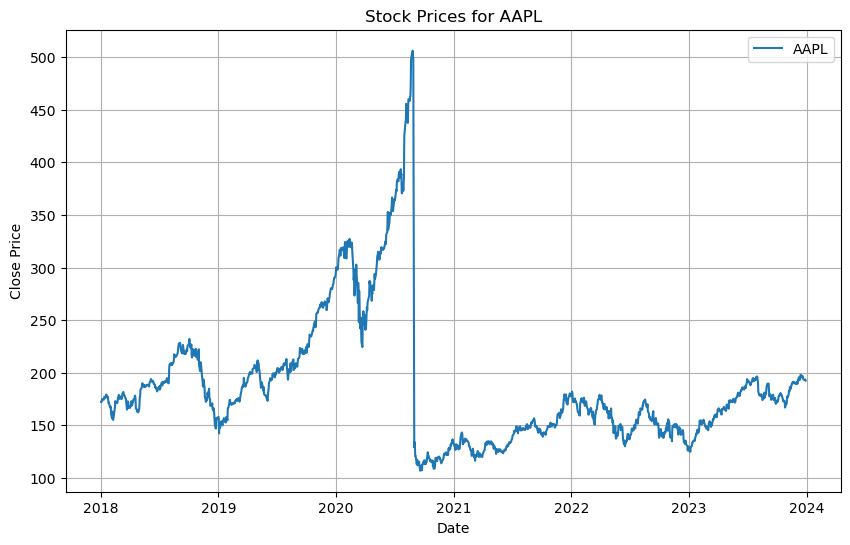

Plot saved for AAPL at AAPL_plot.png


In [9]:
# Read the combined DataFrame from the CSV file
combined_file_path = 'combined_all_years.csv'
combined_df = pd.read_csv(combined_file_path)

# Convert 'file_date' column to datetime format
combined_df['file_date'] = pd.to_datetime(combined_df['file_date'])

# Display the first few rows of the combined DataFrame
print(combined_df.head())

# List of unique tickers
tickers = combined_df['ticker'].unique()

# Print the list of tickers
print("Available tickers:")
print(tickers)

# Ask user to input a ticker
selected_ticker = input("Enter the ticker you want to plot: ")

# Check if the selected ticker is valid
if selected_ticker not in tickers:
    print(f"Ticker {selected_ticker} not found in the data.")
else:
    # Filter the DataFrame for the selected ticker
    ticker_df = combined_df[combined_df['ticker'] == selected_ticker]
    
    # Sort the data by 'file_date'
    ticker_df = ticker_df.sort_values('file_date')
    
    # Plot the data for the selected ticker
    plt.figure(figsize=(10, 6))
    plt.plot(ticker_df['file_date'], ticker_df['close'], label=selected_ticker)
    plt.title(f'Stock Prices for {selected_ticker}')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    
    # Save and show the plot
    plot_path = f'{selected_ticker}_plot.png'
    plt.savefig(plot_path)
    plt.show()
    
    print(f'Plot saved for {selected_ticker} at {plot_path}')


### Dataset Analysis of Combined_DF

In [10]:
# Load the DataFrame from your file
file_path = 'combined_all_years.csv'  # Replace with your actual file path
df = pd.read_csv(file_path)


### Find the number of unique tickers

In [11]:
unique_tickers = df['ticker'].nunique()

print(f'There are {unique_tickers} unique tickers in the dataset.')


There are 18756 unique tickers in the dataset.


##### Save tickers to a master file

In [13]:
# Find the unique tickers
unique_tickers = combined_df['ticker'].unique()

# Convert the unique tickers to a DataFrame
unique_tickers_df = pd.DataFrame(unique_tickers, columns=['ticker'])

# Save the unique tickers to a new CSV file
unique_tickers_df.to_csv('unique_tickers.csv', index=False)

print(f'There are {len(unique_tickers)} unique tickers in the dataset.')
print(f'Unique tickers have been saved to unique_tickers.csv')

There are 18757 unique tickers in the dataset.
Unique tickers have been saved to unique_tickers.csv


#### Timeframe interval of the dataset

In [12]:
# Convert 'file_date' to datetime format
df['file_date'] = pd.to_datetime(df['file_date'])

# Find the minimum and maximum dates
min_date = df['file_date'].min()
max_date = df['file_date'].max()

# Calculate the date range
date_range = max_date - min_date

# Inspect the frequency of dates
date_counts = df['file_date'].value_counts().sort_index()

# Display the results
print(f'Minimum date: {min_date}')
print(f'Maximum date: {max_date}')
print(f'Date range: {date_range}')
print('\nDate frequency:')
print(date_counts)

# Check the intervals between dates
date_intervals = date_counts.index.to_series().diff().dropna().value_counts()

print('\nDate intervals:')
print(date_intervals)

Minimum date: 2018-01-02 00:00:00
Maximum date: 2023-12-29 00:00:00
Date range: 2187 days 00:00:00

Date frequency:
2018-01-02     8168
2018-01-03     8119
2018-01-04     8127
2018-01-05     8115
2018-01-08     8124
              ...  
2023-12-22    10519
2023-12-26    10525
2023-12-27    10535
2023-12-28    10537
2023-12-29    10569
Name: file_date, Length: 1509, dtype: int64

Date intervals:
1 days    1182
3 days     271
4 days      41
2 days      14
dtype: int64


### Get just the S&P 500 Companies

In [38]:
# Load the S&P 500 file
sp500_file_path = 'sp500.csv'  # Replace with the actual file path if different
sp500_df = pd.read_csv(sp500_file_path)

# Extract the list of S&P 500 tickers
sp500_tickers = sp500_df['Symbol'].unique()

# Load the combined dataset
combined_file_path = 'combined_all_years.csv'  # Replace with your actual file path
combined_df = pd.read_csv(combined_file_path)

# Filter the combined dataset to only include rows with tickers in the S&P 500
filtered_df = combined_df[combined_df['ticker'].isin(sp500_tickers)]

# Unindent when you want to re-export data
# # Save the filtered DataFrame to a new CSV file
# filtered_file_path = 'filtered_combined_all_years.csv'
# filtered_df.to_csv(filtered_file_path, index=False)

print(f'Filtered data has been saved to {filtered_file_path}')


Filtered data has been saved to filtered_combined_all_years.csv


In [41]:
print(sp500_df.shape)
sp500_df.head()

(503, 8)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [15]:
# Find the number of Unique Tickers now


# Load the filtered combined dataset
filtered_file_path = 'filtered_combined_all_years.csv'  # Replace with your actual file path
filtered_df = pd.read_csv(filtered_file_path)

# Find the number of unique tickers
unique_tickers_count = filtered_df['ticker'].nunique()

print(f'There are {unique_tickers_count} unique tickers in the filtered dataset.')


There are 499 unique tickers in the filtered dataset.


In [77]:
filtered_df.dtypes

ticker                  object
volume                   int64
open                   float64
close                  float64
high                   float64
low                    float64
window_start             int64
transactions             int64
file_date       datetime64[ns]
dtype: object

### Get the technical indicators as well

In [5]:
# Load the filtered combined dataset
filtered_file_path = 'filtered_combined_all_years.csv'  # Replace with your actual file path
filtered_df = pd.read_csv(filtered_file_path)

# Convert 'file_date' to datetime format
filtered_df['file_date'] = pd.to_datetime(filtered_df['file_date'])

# Calculate Simple Moving Average (SMA)
def calculate_sma(df, window):
    return df['close'].rolling(window=window).mean()

# Calculate Exponential Moving Average (EMA)
def calculate_ema(df, window):
    return df['close'].ewm(span=window, adjust=False).mean()

# Calculate Moving Average Convergence Divergence (MACD)
def calculate_macd(df, short_window, long_window, signal_window):
    short_ema = df['close'].ewm(span=short_window, adjust=False).mean()
    long_ema = df['close'].ewm(span=long_window, adjust=False).mean()
    macd = short_ema - long_ema
    signal = macd.ewm(span=signal_window, adjust=False).mean()
    histogram = macd - signal
    return macd, signal, histogram

# Calculate Relative Strength Index (RSI)
def calculate_rsi(df, window):
    delta = df['close'].diff(1)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi



     ticker    volume    open   close    high     low         window_start  \
2      AAPL  25467275  170.16  172.26  172.30  169.26  1514869200000000000   
463    AAPL  29189598  172.53  172.23  174.55  171.96  1514955600000000000   
924    AAPL  22419009  172.54  173.03  173.47  172.08  1515042000000000000   
1385   AAPL  23504271  173.44  175.00  175.37  173.05  1515128400000000000   
1846   AAPL  20567766  174.35  174.35  175.61  173.93  1515387600000000000   

      transactions  file_date  SMA_50      EMA_50      MACD  MACD_Signal  \
2           177084 2018-01-02     NaN  172.260000  0.000000     0.000000   
463         188331 2018-01-03     NaN  172.258824 -0.002393    -0.000479   
924         153148 2018-01-04     NaN  172.289066  0.059577     0.011532   
1385        152172 2018-01-05     NaN  172.395377  0.264601     0.062146   
1846        138842 2018-01-08     NaN  172.472029  0.370365     0.123790   

      MACD_Histogram  RSI_14  
2           0.000000     NaN  
463        -

In [9]:
# Apply the indicators to the dataset for a sample ticker (AAPL)
sample_ticker = 'AAPL'
sample_df = filtered_df[filtered_df['ticker'] == sample_ticker].copy()

# Ensure the data is sorted by date
sample_df.sort_values('file_date', inplace=True)

# Calculate indicators
sample_df['SMA_50'] = calculate_sma(sample_df, 50)
sample_df['EMA_50'] = calculate_ema(sample_df, 50)
sample_df['MACD'], sample_df['MACD_Signal'], sample_df['MACD_Histogram'] = calculate_macd(sample_df, 12, 26, 9)
sample_df['RSI_14'] = calculate_rsi(sample_df, 14)

# Save the resulting DataFrame to a CSV file
sample_df.to_csv('sample_with_indicators.csv', index=False)

# Display the first few rows of the resulting DataFrame
sample_df.head()

,ticker,volume,open,close,high,low,window_start,transactions,file_date,SMA_50,EMA_50,MACD,MACD_Signal,MACD_Histogram,RSI_14
2,AAPL,25467275,170.16,172.26,172.30,169.26,1514869200000000000,177084,2018-01-02,NaN,172.260000,0.000000,0.000000,0.000000,NaN
463,AAPL,29189598,172.53,172.23,174.55,171.96,1514955600000000000,188331,2018-01-03,NaN,172.258824,-0.002393,-0.000479,-0.001915,NaN
924,AAPL,22419009,172.54,173.03,173.47,172.08,1515042000000000000,153148,2018-01-04,NaN,172.289066,0.059577,0.011532,0.048044,NaN
1385,AAPL,23504271,173.44,175.00,175.37,173.05,1515128400000000000,152172,2018-01-05,NaN,172.395377,0.264601,0.062146,0.202455,NaN
1846,AAPL,20567766,174.35,174.35,175.61,173.93,1515387600000000000,138842,2018-01-08,NaN,172.472029,0.370365,0.123790,0.246575,NaN


In [10]:
# Apply the indicators to the dataset for all tickers
all_tickers = filtered_df['ticker'].unique()

# Initialize an empty list to store DataFrames for each ticker
dfs_with_indicators = []

for ticker in all_tickers:
    ticker_df = filtered_df[filtered_df['ticker'] == ticker].copy()
    ticker_df.sort_values('file_date', inplace=True)
    
    # Calculate indicators
    ticker_df['SMA_50'] = calculate_sma(ticker_df, 50)
    ticker_df['EMA_50'] = calculate_ema(ticker_df, 50)
    ticker_df['MACD'], ticker_df['MACD_Signal'], ticker_df['MACD_Histogram'] = calculate_macd(ticker_df, 12, 26, 9)
    ticker_df['RSI_14'] = calculate_rsi(ticker_df, 14)
    
    # Append the DataFrame with indicators to the list
    dfs_with_indicators.append(ticker_df)

# Concatenate all the DataFrames into a single DataFrame
final_df_with_indicators = pd.concat(dfs_with_indicators)

# Save the resulting DataFrame to a CSV file
final_df_with_indicators.to_csv('final_with_indicators.csv', index=False)

# Display the first few rows of the resulting DataFrame
print(final_df_with_indicators.head())

     ticker   volume   open  close   high     low         window_start  \
0         A  1047830  67.42  67.60  67.89  67.340  1514869200000000000   
461       A  1698899  67.62  69.32  69.49  67.600  1514955600000000000   
922       A  2230839  69.54  68.80  69.82  68.780  1515042000000000000   
1383      A  1632512  68.73  69.90  70.10  68.730  1515128400000000000   
1844      A  1613284  69.73  70.05  70.33  69.545  1515387600000000000   

      transactions  file_date  SMA_50     EMA_50      MACD  MACD_Signal  \
0             8316 2018-01-02     NaN  67.600000  0.000000     0.000000   
461          12808 2018-01-03     NaN  67.667451  0.137208     0.027442   
922          14501 2018-01-04     NaN  67.711865  0.201662     0.062286   
1383         11974 2018-01-05     NaN  67.797674  0.337611     0.117351   
1844         10110 2018-01-08     NaN  67.886000  0.452243     0.184329   

      MACD_Histogram  RSI_14  
0           0.000000     NaN  
461         0.109766     NaN  
922        

In [11]:
final_df_with_indicators.head()

,ticker,volume,open,close,high,low,window_start,transactions,file_date,SMA_50,EMA_50,MACD,MACD_Signal,MACD_Histogram,RSI_14
0,A,1047830,67.42,67.60,67.89,67.340,1514869200000000000,8316,2018-01-02,NaN,67.600000,0.000000,0.000000,0.000000,NaN
461,A,1698899,67.62,69.32,69.49,67.600,1514955600000000000,12808,2018-01-03,NaN,67.667451,0.137208,0.027442,0.109766,NaN
922,A,2230839,69.54,68.80,69.82,68.780,1515042000000000000,14501,2018-01-04,NaN,67.711865,0.201662,0.062286,0.139376,NaN
1383,A,1632512,68.73,69.90,70.10,68.730,1515128400000000000,11974,2018-01-05,NaN,67.797674,0.337611,0.117351,0.220261,NaN
1844,A,1613284,69.73,70.05,70.33,69.545,1515387600000000000,10110,2018-01-08,NaN,67.886000,0.452243,0.184329,0.267914,NaN


In [60]:
AAPL = final_df_with_indicators[final_df_with_indicators['ticker']== 'AAPL'].reset_index()
AAPL = AAPL.drop(columns=['index'])
AAPL

,ticker,volume,open,close,high,low,window_start,transactions,file_date,SMA_50,EMA_50,MACD,MACD_Signal,MACD_Histogram,RSI_14
0,AAPL,25467275,170.16,172.26,172.30,169.260,1514869200000000000,177084,2018-01-02,NaN,172.260000,0.000000,0.000000,0.000000,NaN
1,AAPL,29189598,172.53,172.23,174.55,171.960,1514955600000000000,188331,2018-01-03,NaN,172.258824,-0.002393,-0.000479,-0.001915,NaN
2,AAPL,22419009,172.54,173.03,173.47,172.080,1515042000000000000,153148,2018-01-04,NaN,172.289066,0.059577,0.011532,0.048044,NaN
3,AAPL,23504271,173.44,175.00,175.37,173.050,1515128400000000000,152172,2018-01-05,NaN,172.395377,0.264601,0.062146,0.202455,NaN
4,AAPL,20567766,174.35,174.35,175.61,173.930,1515387600000000000,138842,2018-01-08,NaN,172.472029,0.370365,0.123790,0.246575,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,AAPL,36285270,195.18,193.60,195.41,192.970,1703221200000000000,500504,2023-12-22,185.3988,188.226224,2.636316,3.236689,-0.600373,59.246120
1505,AAPL,28034177,193.61,193.05,193.89,192.830,1703566800000000000,488223,2023-12-26,185.6828,188.415392,2.306308,3.050613,-0.744305,49.031920
1506,AAPL,46390581,192.49,193.15,193.50,191.090,1703653200000000000,548037,2023-12-27,185.9714,188.601063,2.029448,2.846380,-0.816932,52.291552
1507,AAPL,33557566,194.14,193.58,194.66,193.170,1703739600000000000,472373,2023-12-28,186.3000,188.796315,1.823710,2.641846,-0.818136,47.920434


## News Data

### Fetch all news for each ticker between 2018 to 2023

In [62]:
import pandas as pd
import requests
from polygon_api import PolygonAPI  # Ensure this is the correct import for the Polygon API client

# Load the filtered combined dataset
filtered_file_path = 'filtered_combined_all_years.csv'  # Replace with your actual file path
filtered_df = pd.read_csv(filtered_file_path)

# Convert 'file_date' to datetime format
filtered_df['file_date'] = pd.to_datetime(filtered_df['file_date'])

# Find the minimum and maximum dates
min_date = filtered_df['file_date'].min().strftime('%Y-%m-%d')
max_date = filtered_df['file_date'].max().strftime('%Y-%m-%d')

# Find the unique tickers
unique_tickers = filtered_df['ticker'].unique()

print(f'Minimum date: {min_date}')
print(f'Maximum date: {max_date}')
print(f'There are {len(unique_tickers)} unique tickers in the filtered dataset.')

# Initialize PolygonAPI
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'  # Replace with your actual API key
polygon = PolygonAPI(api_key)

# Function to fetch news with pagination
def fetch_news(ticker, min_date, max_date, max_articles=100000):
    all_articles = []
    url = f"https://api.polygon.io/v2/reference/news?ticker={ticker}&published_utc.gte={min_date}&published_utc.lte={max_date}&apiKey={api_key}&limit=1000"
    while len(all_articles) < max_articles:
        response = requests.get(url)
        response.raise_for_status()
        news_data = response.json()
        if not news_data['results']:
            break
        all_articles.extend(news_data['results'])
        if 'next_url' in news_data and news_data['next_url']:
            url = news_data['next_url']
            # Ensure the API key is always included in the next URL
            if "apiKey" not in url:
                url += f"&apiKey={api_key}"
        else:
            break
    return all_articles[:max_articles]

# Fetch news for each ticker between the minimum and maximum dates
all_news = []

for ticker in unique_tickers:
    try:
        news_data = fetch_news(ticker, min_date, max_date)
        for article in news_data:
            all_news.append({
                'ticker': ticker,
                'title': article.get('title', 'No Title'),
                'description': article.get('description', 'No Description'),
                'article_url': article.get('article_url', 'No URL'),
                'published_utc': article.get('published_utc', 'No Date'),
                'author': article.get('author', 'No Author'),
                'source': article['publisher']['name'] if article.get('publisher') else 'No Source'
            })
        print(f"Fetched {len(news_data)} articles for {ticker} from {min_date} to {max_date}")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error occurred for {ticker}: {e}")
    except Exception as e:
        print(f"An error occurred for {ticker}: {e}")

# Create a DataFrame from the collected news
news_df = pd.DataFrame(all_news)

# Save the news DataFrame to a CSV file
news_df.to_csv('master_news_file.csv', index=False)

print('News data has been saved to master_news_file.csv')


In [95]:
# import requests
# import pandas as pd

# # Define the API key and base URL
# api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'
# base_url = 'https://api.polygon.io/v2/reference/news'

# # Function to fetch news for a given ticker within a date range
# def fetch_news(ticker, api_key, start_date, end_date, limit=1000):
#     url = f"{base_url}?ticker={ticker}&published_utc.gte={start_date}&published_utc.lte={end_date}&limit={limit}&apiKey={api_key}"
#     all_news = []

#     while url:
#         response = requests.get(url)
#         if response.status_code == 401:
#             print("Unauthorized request. Please check your API key and permissions.")
#             return all_news
#         if response.status_code == 400:
#             print("Bad request. Please check your parameters.")
#             return all_news
#         response.raise_for_status()
#         data = response.json()

#         # Append results to the all_news list
#         all_news.extend(data['results'])

#         # Check if there is a next_url to paginate
#         url = data.get('next_url')

#     return all_news

# # Fetch news for AAPL from 2018-01-01 to 2023-12-31
# ticker = 'AAPL'
# start_date = '2018-01-01'
# end_date = '2023-12-31'
# news_data = fetch_news(ticker, api_key, start_date, end_date, limit=1000)

# if not news_data:
#     print("No news data fetched. Please check the API key and try again.")
# else:
#     # Process the news data into a DataFrame
#     news_list = []
#     for article in news_data:
#         insights = article.get('insights', [])
#         if not insights:
#             news_list.append({
#                 'ticker': article.get('tickers', ['AAPL'])[0],
#                 'title': article.get('title', 'No Title'),
#                 'description': article.get('description', 'No Description'),
#                 'article_url': article.get('article_url', 'No URL'),
#                 'published_utc': article.get('published_utc', 'No Date'),
#                 'author': article.get('author', 'No Author'),
#                 'source': article['publisher'].get('name') if article.get('publisher') else 'No Source',
#                 'sentiment': 'No Sentiment',
#                 'sentiment_reasoning': 'No Sentiment Reasoning'
#             })
#         else:
#             for insight in insights:
#                 news_list.append({
#                     'ticker': article.get('tickers', ['AAPL'])[0],
#                     'title': article.get('title', 'No Title'),
#                     'description': article.get('description', 'No Description'),
#                     'article_url': article.get('article_url', 'No URL'),
#                     'published_utc': article.get('published_utc', 'No Date'),
#                     'author': article.get('author', 'No Author'),
#                     'source': article['publisher'].get('name') if article.get('publisher') else 'No Source',
#                     'sentiment': insight.get('sentiment', 'No Sentiment'),
#                     'sentiment_reasoning': insight.get('sentiment_reasoning', 'No Sentiment Reasoning')
#                 })

#     news_df = pd.DataFrame(news_list)

#     # Save the news DataFrame to a CSV file
#     news_df.to_csv('aapl_news.csv', index=False)

#     print('News data has been saved to aapl_news.csv')
#     print(news_df.head())


In [86]:
import requests
import pandas as pd

# Define the API key and the base URL
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'
base_url = 'https://api.polygon.io/v2/reference/news'

# Function to fetch news for a given ticker within a date range
def fetch_news(ticker, api_key, start_date, end_date, limit=1000):
    url = f"{base_url}?ticker={ticker}&published_utc.gte={start_date}&published_utc.lte={end_date}&limit={limit}&apiKey={api_key}"
    all_news = []

    while url:
        response = requests.get(url)
        if response.status_code == 401:
            print("Unauthorized request. Please check your API key and permissions.")
            return all_news
        if response.status_code == 400:
            print("Bad request. Please check your parameters.")
            return all_news
        response.raise_for_status()
        data = response.json()

        # Append results to the all_news list
        all_news.extend(data['results'])

        # Check if there is a next_url to paginate
        url = data.get('next_url')

    return all_news

# Fetch news for AAPL from 2018-01-01 to 2023-12-31
ticker = 'AAPL'
start_date = '2018-01-01'
end_date = '2023-12-31'
news_data = fetch_news(ticker, api_key, start_date, end_date, limit=1000)

if not news_data:
    print("No news data fetched. Please check the API key and try again.")
else:
    # Process the news data into a DataFrame
    news_list = []
    for article in news_data:
        insights = article.get('insights', [])
        if not insights:
            news_list.append({
                'ticker': article.get('tickers', ['AAPL'])[0],
                'title': article.get('title', 'No Title'),
                'description': article.get('description', 'No Description'),
                'article_url': article.get('article_url', 'No URL'),
                'published_utc': article.get('published_utc', 'No Date'),
                'author': article.get('author', 'No Author'),
                'source': article['publisher'].get('name') if article.get('publisher') else 'No Source',
                'sentiment': 'No Sentiment',
                'sentiment_reasoning': 'No Sentiment Reasoning'
            })
        else:
            for insight in insights:
                news_list.append({
                    'ticker': article.get('tickers', ['AAPL'])[0],
                    'title': article.get('title', 'No Title'),
                    'description': article.get('description', 'No Description'),
                    'article_url': article.get('article_url', 'No URL'),
                    'published_utc': article.get('published_utc', 'No Date'),
                    'author': article.get('author', 'No Author'),
                    'source': article['publisher'].get('name') if article.get('publisher') else 'No Source',
                    'sentiment': insight.get('sentiment', 'No Sentiment'),
                    'sentiment_reasoning': insight.get('sentiment_reasoning', 'No Sentiment Reasoning')
                })

    news_df = pd.DataFrame(news_list)

    # Save the news DataFrame to a CSV file
    news_df.to_csv('aapl_news.csv', index=False)

    print('News data has been saved to aapl_news.csv')
    print(news_df.head())


Unauthorized request. Please check your API key and permissions.
News data has been saved to aapl_news.csv
  ticker  \
0   AAPL   
1  BRK.B   
2   AAPL   
3   AAPL   
4   COIN   

                                                                                                       title  \
0                                                               PayPal: Don't Keep Hanging On To A Poor Call   
1                                        3 Warren Buffett Dividend Growth Stocks to Buy Now and Hold Forever   
2  Almost Half of Warren Buffett-led Berkshire Hathaway's $370 Billion Portfolio Is Invested in Only 1 Stock   
3                Why Artificial Intelligence (AI) Could Be a Game Changer for This "Magnificent Seven" Stock   
4                      $10,000 Invested in This Growth Stock Could Make You a Fortune Over the Next 10 Years   

                                                                                                                               description  \
0  Pa

In [96]:
news_df.shape

(1000, 9)

In [79]:
news_df.head()

,ticker,title,description,article_url,published_utc,author,source,sentiment,sentiment_reasoning
0,AAPL,PayPal: Don't Keep Hanging On To A Poor Call,"PayPal's stock may have hit its lowest point, but obstacles from competitors and the need for aggressive growth may hinder its success.",https://seekingalpha.com/article/4660510-paypal-dont-keep-hanging-on-to-a-poor-call,2023-12-31T18:30:00Z,JR Research,Seeking Alpha,No Sentiment,No Sentiment Reasoning
1,BRK.B,3 Warren Buffett Dividend Growth Stocks to Buy Now and Hold Forever,These three stocks can keep growing their dividends at a great pace for years to come.,https://www.fool.com/investing/2023/12/31/3-warren-buffett-dividend-growth-stocks-to-buy-now/,2023-12-31T15:00:00Z,newsfeedback@fool.com (Adam Levy),The Motley Fool,No Sentiment,No Sentiment Reasoning
2,AAPL,Almost Half of Warren Buffett-led Berkshire Hathaway's $370 Billion Portfolio Is Invested in Only 1 Stock,This well-known business has been one of the best investments for the conglomerate.,https://www.fool.com/investing/2023/12/31/half-warren-buffett-portfolio-invested-in-1-stock/,2023-12-31T14:53:00Z,newsfeedback@fool.com (Neil Patel),The Motley Fool,No Sentiment,No Sentiment Reasoning
3,AAPL,"Why Artificial Intelligence (AI) Could Be a Game Changer for This ""Magnificent Seven"" Stock","This tech titan hasn't benefited from the growing adoption of AI yet, but that could change in the new year.",https://www.fool.com/investing/2023/12/31/why-artificial-intelligence-could-be-game-changer/,2023-12-31T12:30:00Z,newsfeedback@fool.com (Harsh Chauhan),The Motley Fool,No Sentiment,No Sentiment Reasoning
4,COIN,"$10,000 Invested in This Growth Stock Could Make You a Fortune Over the Next 10 Years","As the cryptocurrency market matures, could Coinbase's strategic advancements make it the next success story for investors?",https://www.fool.com/investing/2023/12/31/10000-invested-in-this-growth-stock-could-make-you/,2023-12-31T10:30:00Z,newsfeedback@fool.com (RJ Fulton),The Motley Fool,No Sentiment,No Sentiment Reasoning


In [58]:
# Load the news dataset
news_df = pd.read_csv('master_news_file.csv')

# Convert 'published_utc' to datetime format
news_df['published_utc'] = pd.to_datetime(news_df['published_utc'])

# Extract the date from 'published_utc'
news_df['published_date'] = news_df['published_utc'].dt.date

# Calculate the number of articles by day
articles_by_day = news_df.groupby('published_date').size()

# Display the result
print(articles_by_day)

# Optionally, you can convert the result to a DataFrame for easier handling
articles_by_day_df = articles_by_day.reset_index(name='article_count')

# Display the first few rows of the DataFrame
print(articles_by_day_df.head())


published_date
2018-01-06     10
2018-11-05     44
2018-11-12     47
2018-11-18     49
2018-11-25     46
             ... 
2023-12-25     84
2023-12-26    360
2023-12-27    514
2023-12-28    463
2023-12-29    504
Length: 1264, dtype: int64
  published_date  article_count
0     2018-01-06             10
1     2018-11-05             44
2     2018-11-12             47
3     2018-11-18             49
4     2018-11-25             46


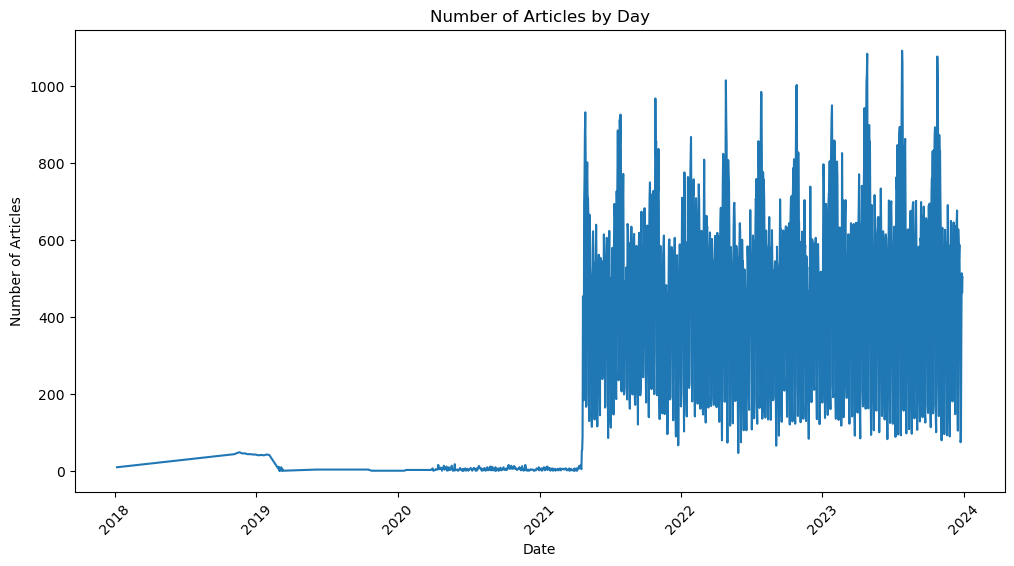

In [59]:
# Plot the number of articles by day
plt.figure(figsize=(12, 6))
articles_by_day.plot()
plt.title('Number of Articles by Day')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

## Analyze the distribution of articles by ticker

In [63]:
# Load the news dataset
news_df = pd.read_csv('master_news_file.csv')

# Calculate the number of articles by ticker
articles_by_ticker = news_df.groupby('ticker').size()

# Convert the result to a DataFrame for easier handling
articles_by_ticker_df = articles_by_ticker.reset_index(name='article_count')

# Sort the DataFrame by article count in descending order
articles_by_ticker_df = articles_by_ticker_df.sort_values(by='article_count', ascending=False)

# Get the top 50 and bottom 50 tickers by article count
top_50_tickers = articles_by_ticker_df.head(50)
bottom_50_tickers = articles_by_ticker_df.tail(50)



In [68]:
# Display the results
print("Top 50 tickers by article count:")
top_50_tickers.head(10)

Top 50 tickers by article count:


,ticker,article_count
32,AMZN,16608
447,TSLA,16075
2,AAPL,15721
322,MSFT,11574
208,GOOGL,10318
343,NVDA,9682
207,GOOG,7549
333,NFLX,6241
137,DIS,5939
303,META,5247


In [69]:
print("\nBottom 50 tickers by article count:")
bottom_50_tickers.head(10)


Bottom 50 tickers by article count:


,ticker,article_count
295,MAS,231
453,TYL,231
355,OTIS,229
112,CPRT,228
103,CMS,227
363,PEG,227
431,TDY,227
167,ES,226
275,LDOS,225
375,PNR,224


### Create a distribution plot of the number of articles between 2018 and 2023

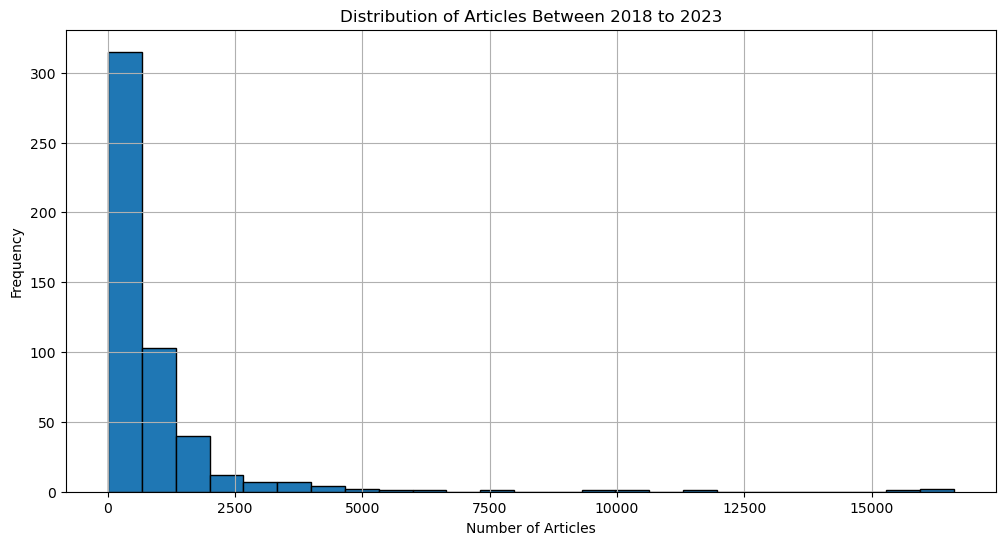

In [71]:
# Load the news dataset
news_df = pd.read_csv('master_news_file.csv')

# Convert 'published_utc' to datetime format
news_df['published_utc'] = pd.to_datetime(news_df['published_utc'])

# Filter the dataset for articles published between 2018 and 2023
filtered_news_df = news_df[(news_df['published_utc'] >= '2018-01-01') & (news_df['published_utc'] <= '2023-12-31')]

# Calculate the number of articles by ticker
articles_by_ticker = filtered_news_df.groupby('ticker').size()

# Create a distribution plot with at least 25 bins
plt.figure(figsize=(12, 6))
plt.hist(articles_by_ticker, bins=25, edgecolor='black')
plt.title('Distribution of Articles Between 2018 to 2023')
plt.xlabel('Number of Articles')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


## Get other Data Points: Financials, Stock Splits, Dividends

In [12]:
# Load the filtered combined dataset
filtered_file_path = 'filtered_combined_all_years.csv'  # Replace with your actual file path
filtered_df = pd.read_csv(filtered_file_path)

# Find the unique tickers
unique_tickers = filtered_df['ticker'].unique()

print(f'There are {len(unique_tickers)} unique tickers in the filtered dataset.')

There are 499 unique tickers in the filtered dataset.


In [13]:
#Function to Fetch Stock Splits

def fetch_stock_splits(ticker, api_key):
    url = f"https://api.polygon.io/v3/reference/splits?ticker={ticker}&apiKey={api_key}"
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

# Function to Fetch Dividends
def fetch_dividends(ticker, api_key):
    url = f"https://api.polygon.io/v3/reference/dividends?ticker={ticker}&apiKey={api_key}"
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

#Function to Fetch Financials
def fetch_financials(ticker, api_key):
    url = f"https://api.polygon.io/vX/reference/financials?ticker={ticker}&apiKey={api_key}"
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

In [23]:
# # Fetch Data for All Tickers and Save to CSV
# all_splits = []
# all_dividends = []
# all_financials = []

# # Fetch data for each unique ticker
# for ticker in unique_tickers:
#     try:
#         splits_data = fetch_stock_splits(ticker, api_key)
#         dividends_data = fetch_dividends(ticker, api_key)
#         financials_data = fetch_financials(ticker, api_key)

#         # Process splits data
#         for split in splits_data['results']:
#             all_splits.append({
#                 'ticker': ticker,
#                 'execution_date': split.get('execution_date', 'N/A'),
#                 'split_from': split.get('split_from', 'N/A'),
#                 'split_to': split.get('split_to', 'N/A')
#             })

#         # Process dividends data
#         for dividend in dividends_data['results']:
#             all_dividends.append({
#                 'ticker': ticker,
#                 'cash_amount': dividend.get('cash_amount', 'N/A'),
#                 'declaration_date': dividend.get('declaration_date', 'N/A'),
#                 'ex_dividend_date': dividend.get('ex_dividend_date', 'N/A'),
#                 'pay_date': dividend.get('pay_date', 'N/A'),
#                 'record_date': dividend.get('record_date', 'N/A'),
#                 'frequency': dividend.get('frequency', 'N/A'),
#                 'dividend_type': dividend.get('dividend_type', 'N/A')
#             })

#         # Process financials data
#         for financial in financials_data['results']:
#             all_financials.append({
#                 'ticker': ticker,
#                 'filing_date': financial.get('filing_date', 'N/A'),
#                 'fiscal_year': financial.get('fiscal_year', 'N/A'),
#                 'fiscal_period': financial.get('fiscal_period', 'N/A'),
#                 'financials': financial.get('financials', 'N/A')  # This is an object, you might want to flatten it based on your needs
#             })

#         print(f"Fetched data for {ticker}")
#     except requests.exceptions.HTTPError as e:
#         print(f"HTTP error occurred for {ticker}: {e}")
#     except Exception as e:
#         print(f"An error occurred for {ticker}: {e}")

# # Convert to DataFrames
# splits_df = pd.DataFrame(all_splits)
# dividends_df = pd.DataFrame(all_dividends)
# financials_df = pd.DataFrame(all_financials)

# # Save to CSV
# splits_df.to_csv('stock_splits_all.csv', index=False)
# dividends_df.to_csv('dividends_all.csv', index=False)
# financials_df.to_csv('financials_all.csv', index=False)

# # Display the DataFrames
# print(splits_df.head())
# print(dividends_df.head())
# print(financials_df.head())

# print('Data has been saved to CSV files.')

Fetched data for A
Fetched data for AAL
Fetched data for AAPL
Fetched data for ABBV
Fetched data for ABT
Fetched data for ACGL
Fetched data for ACN
Fetched data for ADBE
Fetched data for ADI
Fetched data for ADM
Fetched data for ADP
Fetched data for ADSK
Fetched data for AEE
Fetched data for AEP
Fetched data for AES
Fetched data for AFL
Fetched data for AIG
Fetched data for AIZ
Fetched data for AJG
Fetched data for AKAM
Fetched data for ALB
Fetched data for ALGN
Fetched data for ALL
Fetched data for ALLE
Fetched data for AMAT
Fetched data for AMD
Fetched data for AME
Fetched data for AMGN
Fetched data for AMP
Fetched data for AMT
Fetched data for AMZN
Fetched data for ANET
Fetched data for ANSS
Fetched data for AON
Fetched data for AOS
Fetched data for APA
Fetched data for APD
Fetched data for APH
Fetched data for APTV
Fetched data for ARE
Fetched data for ATO
Fetched data for AVB
Fetched data for AVGO
Fetched data for AVY
Fetched data for AWK
Fetched data for AXON
Fetched data for AXP

In [108]:
import requests
import pandas as pd

def fetch_stock_splits(ticker, api_key, start_date, end_date):
    url = f'https://api.polygon.io/v3/reference/splits?ticker={ticker}&execution_date.gte={start_date}&execution_date.lte={end_date}&apiKey={api_key}'
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

def fetch_dividends(ticker, api_key, start_date, end_date):
    url = f'https://api.polygon.io/v3/reference/dividends?ticker={ticker}&ex_dividend_date.gte={start_date}&ex_dividend_date.lte={end_date}&apiKey={api_key}'
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

def fetch_financials(ticker, api_key, start_date, end_date):
    url = f'https://api.polygon.io/vX/reference/financials?ticker={ticker}&filing_date.gte={start_date}&filing_date.lte={end_date}&apiKey={api_key}'
    response = requests.get(url)
    response.raise_for_status()
    return response.json()

# Fetch Data for AAPL and Save to CSV
all_splits = []
all_dividends = []
all_financials = []

start_date = '2018-01-01'
end_date = '2023-12-31'
api_key = 'EgeUS6Duod0x03pFOTZeTBS12aEeF6Ru'  # Replace with your actual API key
ticker = 'AAPL'

try:
    splits_data = fetch_stock_splits(ticker, api_key, start_date, end_date)
    dividends_data = fetch_dividends(ticker, api_key, start_date, end_date)
    financials_data = fetch_financials(ticker, api_key, start_date, end_date)

    # Process splits data
    for split in splits_data.get('results', []):
        all_splits.append({
            'ticker': ticker,
            'execution_date': split.get('execution_date', 'N/A'),
            'split_from': split.get('split_from', 'N/A'),
            'split_to': split.get('split_to', 'N/A')
        })

    # Process dividends data
    for dividend in dividends_data.get('results', []):
        all_dividends.append({
            'ticker': ticker,
            'cash_amount': dividend.get('cash_amount', 'N/A'),
            'declaration_date': dividend.get('declaration_date', 'N/A'),
            'ex_dividend_date': dividend.get('ex_dividend_date', 'N/A'),
            'pay_date': dividend.get('pay_date', 'N/A'),
            'record_date': dividend.get('record_date', 'N/A'),
            'frequency': dividend.get('frequency', 'N/A'),
            'dividend_type': dividend.get('dividend_type', 'N/A')
        })

    # Process financials data
    for financial in financials_data.get('results', []):
        all_financials.append({
            'ticker': ticker,
            'filing_date': financial.get('filing_date', 'N/A'),
            'fiscal_year': financial.get('fiscal_year', 'N/A'),
            'fiscal_period': financial.get('fiscal_period', 'N/A'),
            'financials': financial.get('financials', 'N/A')  # This is an object, you might want to flatten it based on your needs
        })

    print(f"Fetched data for {ticker}")
except requests.exceptions.HTTPError as e:
    print(f"HTTP error occurred for {ticker}: {e}")
except Exception as e:
    print(f"An error occurred for {ticker}: {e}")

# Convert to DataFrames
splits_df = pd.DataFrame(all_splits)
dividends_df = pd.DataFrame(all_dividends)
financials_df = pd.DataFrame(all_financials)

# Save to CSV
splits_df.to_csv(f'stock_splits_{ticker}.csv', index=False)
dividends_df.to_csv(f'dividends_{ticker}.csv', index=False)
financials_df.to_csv(f'financials_{ticker}.csv', index=False)

# Display the DataFrames
print(splits_df.head())
print(dividends_df.head())
print(financials_df.head())

print('Data has been saved to CSV files.')


Fetched data for AAPL
  ticker execution_date  split_from  split_to
0   AAPL     2020-08-31           1         4
  ticker  cash_amount declaration_date ex_dividend_date    pay_date  \
0   AAPL         0.24       2023-11-02       2023-11-10  2023-11-16   
1   AAPL         0.24       2023-08-03       2023-08-11  2023-08-17   
2   AAPL         0.24       2023-05-04       2023-05-12  2023-05-18   
3   AAPL         0.23       2023-02-02       2023-02-10  2023-02-16   
4   AAPL         0.23       2022-10-27       2022-11-04  2022-11-10   

  record_date  frequency dividend_type  
0  2023-11-13          4            CD  
1  2023-08-14          4            CD  
2  2023-05-15          4            CD  
3  2023-02-13          4            CD  
4  2022-11-07          4            CD  
  ticker filing_date fiscal_year fiscal_period  \
0   AAPL  2023-11-03        2023            FY   
1   AAPL  2023-08-04        2023            Q3   
2   AAPL  2023-05-05        2023            Q2   
3   AAPL  202

In [109]:
print(financials_df.shape)
financials_df.head()

(10, 5)


ticker filing_date fiscal_year fiscal_period  \
0   AAPL  2023-11-03        2023            FY   
1   AAPL  2023-08-04        2023            Q3   
2   AAPL  2023-05-05        2023            Q2   
3   AAPL  2023-02-03        2023            Q1   
4   AAPL  2022-10-28        2022            FY   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [110]:
print(splits_df.shape)
splits_df.head()

(1, 4)


,ticker,execution_date,split_from,split_to
0,AAPL,2020-08-31,1,4


In [34]:
print(dividends_df.shape)
dividends_df.head()

(4071, 8)


,ticker,cash_amount,declaration_date,ex_dividend_date,pay_date,record_date,frequency,dividend_type
0,A,0.236,2024-05-22,2024-07-02,2024-07-24,2024-07-02,4,CD
1,A,0.236,2024-02-21,2024-04-01,2024-04-24,2024-04-02,4,CD
2,A,0.236,2023-11-15,2023-12-29,2024-01-24,2024-01-02,4,CD
3,A,0.225,2023-09-20,2023-10-02,2023-10-25,2023-10-03,4,CD
4,A,0.225,2023-05-17,2023-06-30,2023-07-26,2023-07-03,4,CD


In [104]:

AAPL_financials = financials_df[financials_df['ticker']=='AAPL'].reset_index(drop=True)
print(AAPL_financials.shape)
AAPL_financials.head()

(4957, 5)
(10, 5)


ticker filing_date fiscal_year fiscal_period  \
0   AAPL         N/A                       TTM   
1   AAPL  2024-05-03        2024            Q2   
2   AAPL  2024-02-02        2024            Q1   
3   AAPL         N/A        2023            Q4   
4   AAPL  2023-11-03        2023            FY   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [103]:
AAPL_splits = splits_df[splits_df['ticker']=='AAPL'].reset_index(drop=True)
print(AAPL_splits.shape)
AAPL_splits.head()

(3, 4)


,ticker,execution_date,split_from,split_to
0,AAPL,2020-08-31,1.0,4.0
1,AAPL,2014-06-09,1.0,7.0
2,AAPL,2005-02-28,1.0,2.0


In [105]:
AAPL_dividends = dividends_df[dividends_df['ticker']=='AAPL'].reset_index(drop=True)
print(AAPL_dividends.shape)
AAPL_dividends.head(50)

(10, 8)


,ticker,cash_amount,declaration_date,ex_dividend_date,pay_date,record_date,frequency,dividend_type
0,AAPL,0.25,2024-05-02,2024-05-10,2024-05-16,2024-05-13,4,CD
1,AAPL,0.24,2024-02-01,2024-02-09,2024-02-15,2024-02-12,4,CD
2,AAPL,0.24,2023-11-02,2023-11-10,2023-11-16,2023-11-13,4,CD
3,AAPL,0.24,2023-08-03,2023-08-11,2023-08-17,2023-08-14,4,CD
4,AAPL,0.24,2023-05-04,2023-05-12,2023-05-18,2023-05-15,4,CD
5,AAPL,0.23,2023-02-02,2023-02-10,2023-02-16,2023-02-13,4,CD
6,AAPL,0.23,2022-10-27,2022-11-04,2022-11-10,2022-11-07,4,CD
7,AAPL,0.23,2022-07-28,2022-08-05,2022-08-11,2022-08-08,4,CD
8,AAPL,0.23,2022-04-28,2022-05-06,2022-05-12,2022-05-09,4,CD
9,AAPL,0.22,2022-01-27,2022-02-04,2022-02-10,2022-02-07,4,CD
